# Bank Marketing 

**Bank Marketing Dataset** from the UCI Machine Learning Repository  
🔗 https://archive.ics.uci.edu/dataset/222/bank+marketing


In [1]:
import sys, subprocess
try:
    import ucimlrepo
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo", "-q"])
    import ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42  
np.random.seed(RANDOM_STATE)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Data Loading

In [3]:
bank = fetch_ucirepo(id=222)

X_raw = bank.data.features.copy()
y_raw = bank.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [4]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  y            45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB

Missing values per column:
age                0
job              288
marital            0
educ

In [2]:
## basic analysis explaratory

Target column: 'y'

Class distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Class proportions:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


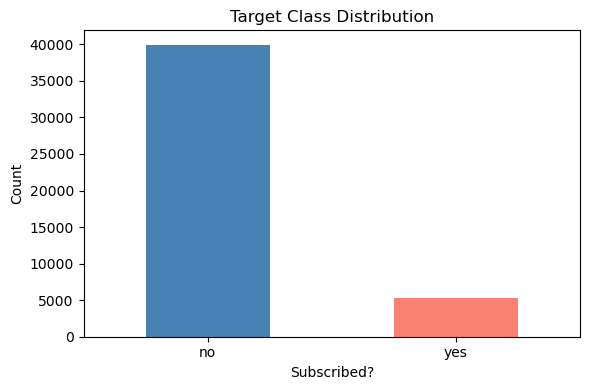

In [5]:
target_col = y_raw.columns[0]
print(f"Target column: '{target_col}'")
print("\nClass distribution:")
print(df[target_col].value_counts())
print("\nClass proportions:")
print(df[target_col].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(6,4))
df[target_col].value_counts().plot(kind='bar', ax=ax, color=['steelblue','salmon'])
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Subscribed?')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [ ]:
numerical featrue districtuions on historgrams 

Numerical features: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']


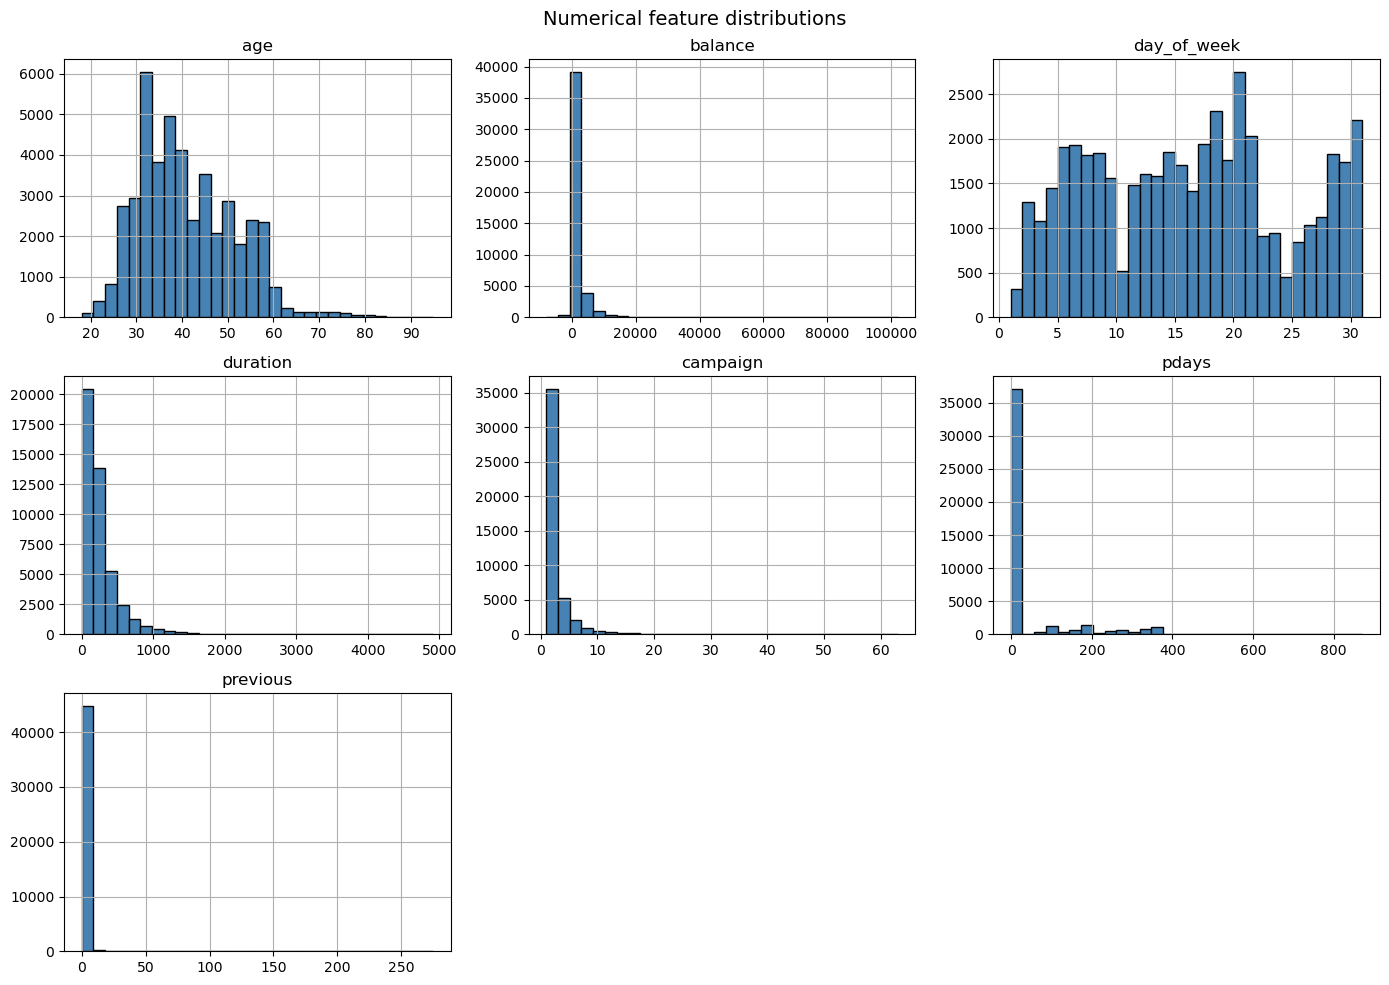

In [6]:
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical features:", numeric_cols)

X_raw[numeric_cols].hist(figsize=(14,10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Numerical feature distributions', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
checking catergorical features to know the cardianlity of each category to see how widde the hot encoding will be

In [7]:
# Categorical features
categorical_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", categorical_cols)

for col in categorical_cols:
    print(f"\n{col}: {X_raw[col].nunique()} unique values")
    print(X_raw[col].value_counts().head(10))

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

job: 11 unique values
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
Name: count, dtype: int64

marital: 3 unique values
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education: 3 unique values
education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64

default: 2 unique values
default
no     44396
yes      815
Name: count, dtype: int64

housing: 2 unique values
housing
yes    25130
no     20081
Name: count, dtype: int64

loan: 2 unique values
loan
no     37967
yes     7244
Name: count, dtype: int64

contact: 2 unique values
contact
cellular     29285
telephone     2906
Name: count, dtype: int64

month: 12 unique values
m

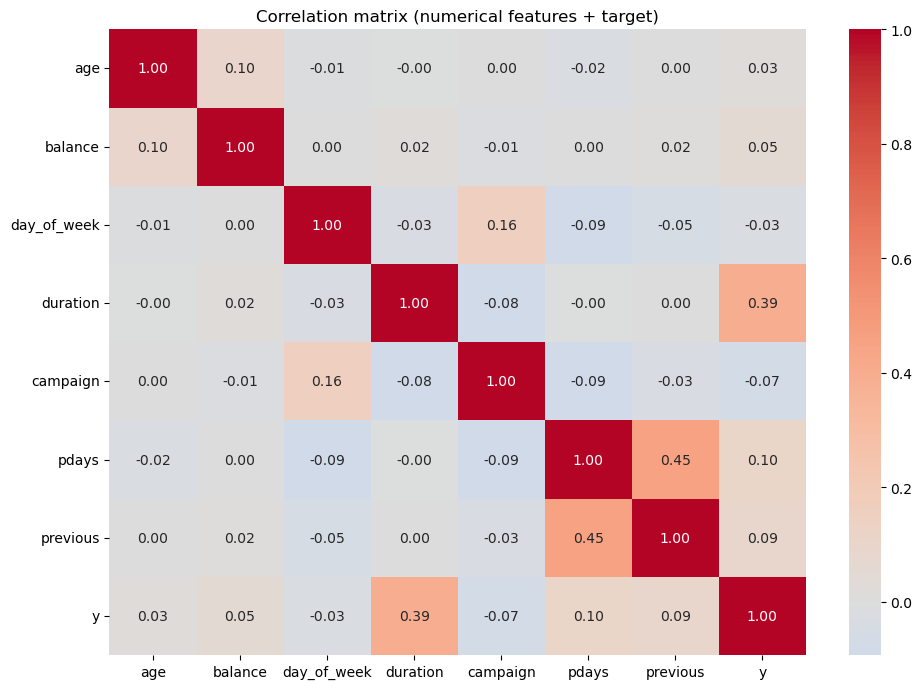

In [8]:
df_corr = df.copy()
df_corr[target_col] = (df_corr[target_col] == 'yes').astype(int)

plt.figure(figsize=(10,7))
sns.heatmap(df_corr[numeric_cols + [target_col]].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation matrix (numerical features + target)')
plt.tight_layout(); plt.show()

In [8]:
1. drop duration
2. encode target as 0 and 1
3. encode categories with one hot encoding --- NO LABEL ENCODER since the treatment will be mistaken since the higher number might take higher value 
4. numerical scaling (standard scaler) -- NOT min max to use the Guassian distribution, and since min and max keeps the dateat between a tiny range
5. create the pipeline and column transformer

SyntaxError: invalid syntax (1680617493.py, line 1)

In [ ]:
split into numerical and categorical features

In [9]:
X = X_raw.drop(columns=['duration']).copy()
y = (y_raw[target_col] == 'yes').astype(int).values  # encode target as 0/1

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print(f"\nFinal feature count: {X.shape[1]} (target: {target_col} → 0/1)")
print(f"Class balance after encoding: {np.bincount(y)} → ratio = {y.mean():.4f}")

Numeric features: ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Final feature count: 15 (target: y → 0/1)
Class balance after encoding: [39922  5289] → ratio = 0.1170


In [ ]:
apply column transformer to the numerical features, and categorical features 


In [10]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, #full features and target
    test_size=0.2, # 20% goes to test and 80% to train
    stratify=y, # forces both train and test sets to keep the original class ratio
    random_state=RANDOM_STATE # same split every run
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class balance: {y_train.mean():.4f}")
print(f"Test  class balance: {y_test.mean():.4f}  (should match — confirms stratification works)")

Training set: 36168 samples
Test set:     9043 samples
Train class balance: 0.1170
Test  class balance: 0.1170  (should match — confirms stratification works)


In [12]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model"):
    """Train, evaluate, and return a dict of metrics on both train and test sets."""
    model.fit(X_tr, y_tr) # fit on training data
    y_pred_train = model.predict(X_tr) #predict labels on both sets so we can detect overfitting later
    y_pred_test = model.predict(X_te) # large gap between train and test scores = over fitting 
    
    try:
        y_score_test = model.predict_proba(X_te)[:,1]
    except AttributeError:
        y_score_test = model.decision_function(X_te)
    
    metrics = {
        'model': name,
        'train_accuracy': accuracy_score(y_tr, y_pred_train), #simple but wont be very usefull 
        'test_accuracy':  accuracy_score(y_te, y_pred_test),
        'train_f1':       f1_score(y_tr, y_pred_train), # prediction and recall checking
        'test_f1':        f1_score(y_te, y_pred_test),
        'test_precision': precision_score(y_te, y_pred_test), #how many successful finds we got
        'test_recall':    recall_score(y_te, y_pred_test),  # how many real YES we got
        'test_roc_auc':   roc_auc_score(y_te, y_score_test) #how good i t was at separating the yeses and nos
    }
    return metrics, y_pred_test

print("Evaluation helper defined.")

Evaluation helper defined.


In [ ]:
we use pipelines to prevent data leakage
when pipeline.fit is called the preprocessor learns scaling and encoding parameters from X_train only
when pipeline.predict is called, the test data is transformed using the parameters learnerd on trainging ((never re-learned on test))

In [13]:
dt_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(random_state=RANDOM_STATE))
])

nb_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  GaussianNB()) #no random_state (deterministic)
])

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(random_state=RANDOM_STATE, 
                                    n_jobs=-1)) #use all cpu cores in parallel
])

baseline_results = []
for name, pipe in [('Decision Tree (baseline)', dt_pipe),
                   ('Naive Bayes (baseline)',   nb_pipe),
                   ('Random Forest (baseline)', rf_pipe)]:
    metrics, _ = evaluate_model(pipe, X_train, y_train, X_test, y_test, name)
    baseline_results.append(metrics)

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,model,train_accuracy,test_accuracy,train_f1,test_f1,test_precision,test_recall,test_roc_auc
0,Decision Tree (baseline),1.000000,0.830919,1.000000,0.312809,0.298201,0.328922,0.613178
1,Naive Bayes (baseline),0.840798,0.845184,0.396815,0.412259,0.370846,0.464083,0.751441
2,Random Forest (baseline),0.999972,0.895389,0.999882,0.354707,0.637255,0.245747,0.788788


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # split in folds and maintain class ration 88/12

for name, pipe in [('Decision Tree', dt_pipe),
                   ('Naive Bayes',   nb_pipe),
                   ('Random Forest', rf_pipe)]:
    scores = cross_val_score(pipe, X_train, y_train, scoring='f1', cv=cv, n_jobs=-1)
    print(f"{name:20s}  CV F1: {scores.mean():.4f} (+/- {scores.std():.4f})") # measure mean and std deviation for consistency 

Decision Tree         CV F1: 0.3154 (+/- 0.0185)
Naive Bayes           CV F1: 0.3925 (+/- 0.0065)
Random Forest         CV F1: 0.3265 (+/- 0.0187)


In [ ]:
see what are the most important features that works in the correct decision making when we trained the data

Top 15 most important features (post-encoding):
                feature  importance
0               balance    0.171892
1                   age    0.147107
2           day_of_week    0.124532
3              campaign    0.062313
4                 pdays    0.048032
5      poutcome_success    0.047455
6              previous    0.024077
7   education_secondary    0.015977
8    education_tertiary    0.014032
9             month_apr    0.013842
10       job_technician    0.013618
11       job_management    0.012989
12           housing_no    0.012463
13          housing_yes    0.012418
14      marital_married    0.012196


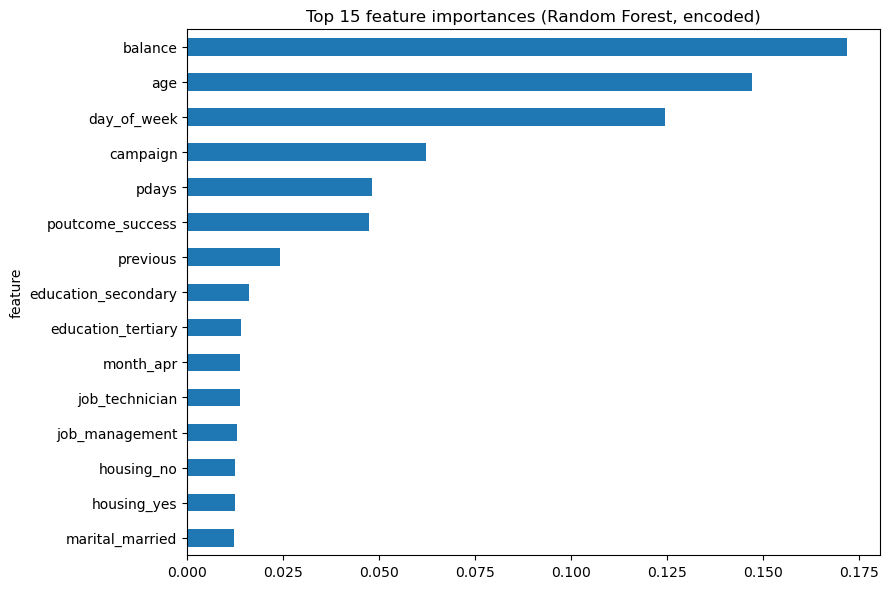

In [15]:
rf_pipe.fit(X_train, y_train)

# get feature names after one hot encoding
ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
ohe_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + ohe_names

importances = rf_pipe.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})\
           .sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 15 most important features (post-encoding):")
print(imp_df.head(15))

plt.figure(figsize=(9,6))
imp_df.head(15).plot.barh(x='feature', y='importance', legend=False, ax=plt.gca())
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances (Random Forest, encoded)')
plt.tight_layout(); plt.show()

In [16]:
K = 15  # nr of fearues to keep

slim_dt = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=mutual_info_classif, k=K)),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=8))
])

slim_nb = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=mutual_info_classif, k=K)),
    ('clf', GaussianNB())
])

slim_rf = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=mutual_info_classif, k=K)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

slim_results = []
for name, pipe in [(f'Decision Tree (slim k={K})', slim_dt),
                   (f'Naive Bayes (slim k={K})',   slim_nb),
                   (f'Random Forest (slim k={K})', slim_rf)]:
    metrics, _ = evaluate_model(pipe, X_train, y_train, X_test, y_test, name)
    slim_results.append(metrics)

pd.DataFrame(slim_results)

,model,train_accuracy,test_accuracy,train_f1,test_f1,test_precision,test_recall,test_roc_auc
0,Decision Tree (slim k=15),0.899663,0.890965,0.355074,0.302687,0.601124,0.202268,0.730673
1,Naive Bayes (slim k=15),0.853323,0.855247,0.340748,0.352941,0.369948,0.337429,0.730635
2,Random Forest (slim k=15),0.996212,0.874710,0.983583,0.305334,0.434555,0.235350,0.703416
